# Probe Evaluation: Activation Probes for High-Stakes Detection

Configurable notebook for training and evaluating linear probes on LLM activations.

**Supports:**
- Multiple models: Llama 3.1 8B, Llama 3.3 70B, Gemma 3
- Layer sweep: evaluate probes at any set of layers
- Cross-lingual evaluation: English vs Indonesian (when translations available)
- Caching: all activations and probes cached to disk, re-runs are instant

**Requires:** `experiments/lib/` shared library. Run `setup_lambda.sh` on remote or install deps manually.

## Part 0: Setup

In [1]:
import importlib
missing = [pkg for pkg in ["bitsandbytes", "dotenv", "accelerate"] if not importlib.util.find_spec(pkg)]
if missing:
    %pip install -U bitsandbytes python-dotenv accelerate transformers scikit-learn tqdm

In [2]:
import sys
import json
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

sys.path.insert(0, str(Path("..").resolve()))

from lib.env import (
    detect_environment, resolve_base_dir, setup_paths, get_device,
    get_gpu_vram_gb, recommend_batch_size, free_gpu_memory, setup_hf_auth,
    download_from_colab, list_cache,
)
from lib.data import ensure_datasets, get_dataset_paths, load_dataset, load_jsonl
from lib.model import load_model, get_model_short_name, MODEL_REGISTRY
from lib.activations import get_activations_cached
from lib.probe import LinearProbe
from lib.evaluation import evaluate_probe, analyze_errors, bootstrap_auroc_ci

# --- Configuration ---
# MODEL_NAME      = "meta-llama/Llama-3.1-8B-Instruct"
# LAYERS          = [12, 16, 20, 26, 31]
# EVAL_INDONESIAN = True

# --- Configuration ---
MODEL_NAME      = "google/gemma-3-12b-it"
LAYERS          = [8, 16, 24, 31, 32, 41, 47]
EVAL_INDONESIAN = True

# Reproducible multi-seed: master seed generates N child seeds
MASTER_SEED = 20250214
N_SEEDS     = 10
rng_master  = np.random.RandomState(MASTER_SEED)
SEEDS       = rng_master.randint(0, 2**31, size=N_SEEDS).tolist()

# Bootstrap CI config
N_BOOTSTRAP = 1000
CI_LEVEL    = 0.95

# --- Derived settings ---
ENV          = detect_environment()
BASE_DIR     = resolve_base_dir()
DEVICE       = get_device()
VRAM_GB      = get_gpu_vram_gb()
paths        = setup_paths(BASE_DIR)
DATA_DIR     = paths["data_dir"]
CACHE_DIR    = paths["cache_dir"]
MODEL_SHORT  = get_model_short_name(MODEL_NAME)
CACHE_PREFIX = f"v2b_{MODEL_SHORT}"
PARAMS_B     = MODEL_REGISTRY.get(MODEL_NAME, {}).get("params_b", 8)
BATCH_SIZE   = recommend_batch_size(VRAM_GB, PARAMS_B)

# Figure output directory
FIG_DIR = CACHE_DIR / "figures" / MODEL_SHORT
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model:        {MODEL_NAME}")
print(f"Short name:   {MODEL_SHORT}")
print(f"Cache prefix: {CACHE_PREFIX}")
print(f"Layers:       {LAYERS}")
print(f"Indonesian:   {EVAL_INDONESIAN}")
print(f"Environment:  {ENV}")
print(f"Device:       {DEVICE}")
print(f"VRAM:         {VRAM_GB:.1f} GB")
print(f"Batch size:   {BATCH_SIZE}")
print(f"Seeds:        {SEEDS}")
print(f"Figures:      {FIG_DIR}")

Model:        google/gemma-3-12b-it
Short name:   gemma3_12b
Cache prefix: v2b_gemma3_12b
Layers:       [8, 16, 24, 31, 32, 41, 47]
Indonesian:   True
Environment:  remote
Device:       cuda
VRAM:         39.5 GB
Batch size:   8
Seeds:        [966309463, 1936015474, 50265558, 245223150, 735961528, 1483462291, 1473454425, 1706659384, 1157150576, 274541964]
Figures:      /lambda/nfs/default-filesystem/bluedot-project/experiments/cache/figures/gemma3_12b


## Part 1: Auth + Load Model

In [3]:
setup_hf_auth()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to HuggingFace


In [4]:
model, tokenizer = load_model(MODEL_NAME)

Loading google/gemma-3-12b-it...
  Device: cuda | VRAM: 39.5 GB | Precision: 8-bit


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

  Layers: 48 | Hidden dim: 3840 | Vocab: 262208


## Part 2: Load Data

In [5]:
DATASET_PATHS  = ensure_datasets(DATA_DIR)
train_data     = load_dataset(DATASET_PATHS["train"])
test_data      = load_dataset(DATASET_PATHS["test"])
anthropic_test = load_dataset(DATASET_PATHS["anthropic_test"])
toolace_test   = load_dataset(DATASET_PATHS["toolace_test"])

y_train     = np.array([e.label for e in train_data])
y_test      = np.array([e.label for e in test_data])
y_anthropic = np.array([e.label for e in anthropic_test])
y_toolace   = np.array([e.label for e in toolace_test])

print("English datasets:")
print(f"  Train:      {len(train_data):>5} ({y_train.sum()} high)")
print(f"  Test:       {len(test_data):>5} ({y_test.sum()} high)")
print(f"  Anthropic:  {len(anthropic_test):>5} ({y_anthropic.sum()} high)")
print(f"  ToolACE:    {len(toolace_test):>5} ({y_toolace.sum()} high)")

# Indonesian datasets (if enabled)
id_test_data = id_anthropic_test = id_toolace_test = None
y_id_test = y_id_anthropic = y_id_toolace = None

if EVAL_INDONESIAN:
    ID_DIR = DATA_DIR / "indonesian"

    # Load and filter: remove refusals (rows where translation kept original English)
    # Refusals have identical text to English version, which contaminates cross-lingual eval
    def filter_refusals(id_examples, en_examples):
        """Remove examples where Indonesian text matches English (API refusals)."""
        filtered = []
        n_refusals = 0
        for id_ex, en_ex in zip(id_examples, en_examples):
            # Compare first user message content
            id_text = next((m["content"] for m in id_ex.messages if m["role"] == "user"), "")
            en_text = next((m["content"] for m in en_ex.messages if m["role"] == "user"), "")
            if id_text == en_text:
                n_refusals += 1
            else:
                filtered.append(id_ex)
        if n_refusals > 0:
            print(f"    Filtered {n_refusals} refusals (kept original English text)")
        return filtered

    id_test_data_raw  = load_dataset(ID_DIR / "synthetic_test_id.jsonl")
    id_anthropic_raw  = load_dataset(ID_DIR / "anthropic_test_id.jsonl")
    id_toolace_raw    = load_dataset(ID_DIR / "toolace_test_id.jsonl")

    id_test_data      = filter_refusals(id_test_data_raw, test_data)
    id_anthropic_test = filter_refusals(id_anthropic_raw, anthropic_test)
    id_toolace_test   = filter_refusals(id_toolace_raw, toolace_test)

    y_id_test      = np.array([e.label for e in id_test_data])
    y_id_anthropic = np.array([e.label for e in id_anthropic_test])
    y_id_toolace   = np.array([e.label for e in id_toolace_test])

    print(f"\nIndonesian datasets (refusals filtered):")
    print(f"  Test:       {len(id_test_data):>5} ({y_id_test.sum()} high)")
    print(f"  Anthropic:  {len(id_anthropic_test):>5} ({y_id_anthropic.sum()} high)")
    print(f"  ToolACE:    {len(id_toolace_test):>5} ({y_id_toolace.sum()} high)")

Checking datasets...
  Already exists: train.jsonl
  Already exists: test.jsonl
  Already exists: anthropic_test_balanced_apr_23.jsonl
  Already exists: toolace_test_balanced_apr_22.jsonl
All datasets ready.
English datasets:
  Train:       8000 (4000 high)
  Test:        2000 (1000 high)
  Anthropic:   2984 (1492 high)
  ToolACE:      734 (367 high)
    Filtered 1 refusals (kept original English text)
    Filtered 25 refusals (kept original English text)
    Filtered 1 refusals (kept original English text)

Indonesian datasets (refusals filtered):
  Test:        1950 (1000 high)
  Anthropic:   2959 (1468 high)
  ToolACE:      733 (367 high)


## Part 3: Extract Activations, Train Probes (Multi-Seed), & Evaluate

For each layer in LAYERS:
1. Extract activations (cached to disk — only computed once per model/layer)
2. For each of N_SEEDS random seeds, train a probe and collect predictions
3. Compute AUROC with bootstrap 95% CIs for each seed
4. Aggregate: mean +/- std across seeds

In [6]:
# Structure: all_results[layer][seed_idx] = {dataset: {auroc, ci_lower, ci_upper, accuracy, ...}}
# Also store: all_probs[layer][seed_idx] = {dataset: probs_array} for downstream analysis
all_results = {}
all_probs   = {}

DATASETS = ["synthetic", "anthropic", "toolace"]

for layer in LAYERS:
    print(f"\n{'='*65}")
    print(f"LAYER {layer}")
    print(f"{'='*65}")

    # -- Extract activations (cached, only runs once per model/layer) --
    X_train = get_activations_cached(
        model, tokenizer, train_data, layer,
        cache_name="train", cache_dir=CACHE_DIR,
        cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
    )
    X_test = get_activations_cached(
        model, tokenizer, test_data, layer,
        cache_name="test_synthetic", cache_dir=CACHE_DIR,
        cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
    )
    X_anthropic = get_activations_cached(
        model, tokenizer, anthropic_test, layer,
        cache_name="anthropic_test", cache_dir=CACHE_DIR,
        cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
    )
    X_toolace = get_activations_cached(
        model, tokenizer, toolace_test, layer,
        cache_name="toolace_test", cache_dir=CACHE_DIR,
        cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
    )
    free_gpu_memory()

    X_id_test = X_id_anthropic = X_id_toolace = None
    if EVAL_INDONESIAN:
        X_id_test = get_activations_cached(
            model, tokenizer, id_test_data, layer,
            cache_name="id_test_synthetic", cache_dir=CACHE_DIR,
            cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
        )
        X_id_anthropic = get_activations_cached(
            model, tokenizer, id_anthropic_test, layer,
            cache_name="id_anthropic_test", cache_dir=CACHE_DIR,
            cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
        )
        X_id_toolace = get_activations_cached(
            model, tokenizer, id_toolace_test, layer,
            cache_name="id_toolace_test", cache_dir=CACHE_DIR,
            cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
        )
        free_gpu_memory()

    # eval datasets: (name_suffix, X, y)
    eval_sets = [
        ("synthetic", X_test,      y_test),
        ("anthropic", X_anthropic, y_anthropic),
        ("toolace",   X_toolace,   y_toolace),
    ]
    if EVAL_INDONESIAN:
        eval_sets += [
            ("id_synthetic", X_id_test,      y_id_test),
            ("id_anthropic", X_id_anthropic, y_id_anthropic),
            ("id_toolace",   X_id_toolace,   y_id_toolace),
        ]

    # -- Multi-seed probe training --
    layer_results = {}
    layer_probs   = {}

    for seed_idx, seed in enumerate(SEEDS):
        probe = LinearProbe(C=1e-3, random_state=seed)
        probe.fit(X_train, y_train)

        seed_results = {}
        seed_probs   = {}
        for ds_name, X_eval, y_eval in eval_sets:
            probs = probe.predict_proba(X_eval)
            preds = (probs >= 0.5).astype(int)

            auroc, ci_lo, ci_hi = bootstrap_auroc_ci(
                y_eval, probs, n_bootstrap=N_BOOTSTRAP, ci=CI_LEVEL, seed=seed,
            )
            seed_results[ds_name] = {
                "auroc":    auroc,
                "ci_lower": ci_lo,
                "ci_upper": ci_hi,
                "accuracy": float((preds == y_eval).mean()),
            }
            seed_probs[ds_name] = probs

        layer_results[seed_idx] = seed_results
        layer_probs[seed_idx]   = seed_probs

    # save the first seed's probe as the "canonical" one (for error analysis etc.)
    canonical_probe = LinearProbe(C=1e-3, random_state=SEEDS[0])
    canonical_probe.fit(X_train, y_train)
    canonical_probe.save(CACHE_DIR / f"{CACHE_PREFIX}_probe_layer{layer}.pkl")

    all_results[layer] = layer_results
    all_probs[layer]   = layer_probs
    free_gpu_memory()

    # -- Print summary for this layer --
    print(f"\n  AUROC across {N_SEEDS} seeds (mean +/- std [95% bootstrap CI of seed 0]):")
    for ds_name in [ds for ds, _, _ in eval_sets]:
        aurocs = [layer_results[s][ds_name]["auroc"] for s in range(N_SEEDS)]
        ci_lo  = layer_results[0][ds_name]["ci_lower"]
        ci_hi  = layer_results[0][ds_name]["ci_upper"]
        print(f"    {ds_name:15s}: {np.mean(aurocs):.4f} +/- {np.std(aurocs):.4f}  "
              f"[{ci_lo:.4f}, {ci_hi:.4f}]")

# -- Summary table across all layers --
print(f"\n{'='*65}")
print(f"AUROC SUMMARY: {MODEL_SHORT} ({N_SEEDS} seeds)")
print(f"{'='*65}")

en_ds_names = ["synthetic", "anthropic", "toolace"]
id_ds_names = ["id_synthetic", "id_anthropic", "id_toolace"] if EVAL_INDONESIAN else []

header = f"{'Layer':>6}"
for ds in en_ds_names:
    header += f" | {'Orig '+ds:>20}"
for ds in id_ds_names:
    header += f" | {'ID '+ds.replace('id_',''):>20}"
print(header)
print("-" * len(header))

for layer in LAYERS:
    row = f"{layer:>6}"
    for ds in en_ds_names + id_ds_names:
        aurocs = [all_results[layer][s][ds]["auroc"] for s in range(N_SEEDS)]
        row += f" | {np.mean(aurocs):>8.4f} +/- {np.std(aurocs):.4f}"
    print(row)


LAYER 8
Loading from cache: v2b_gemma3_12b_train_layer8.npy
Loading from cache: v2b_gemma3_12b_test_synthetic_layer8.npy
Loading from cache: v2b_gemma3_12b_anthropic_test_layer8.npy
Loading from cache: v2b_gemma3_12b_toolace_test_layer8.npy
Loading from cache: v2b_gemma3_12b_id_test_synthetic_layer8.npy
Loading from cache: v2b_gemma3_12b_id_anthropic_test_layer8.npy
Loading from cache: v2b_gemma3_12b_id_toolace_test_layer8.npy

  AUROC across 10 seeds (mean +/- std [95% bootstrap CI of seed 0]):
    synthetic      : 0.9941 +/- 0.0000  [0.9918, 0.9961]
    anthropic      : 0.7872 +/- 0.0000  [0.7714, 0.8037]
    toolace        : 0.7850 +/- 0.0000  [0.7519, 0.8173]
    id_synthetic   : 0.9898 +/- 0.0000  [0.9862, 0.9928]
    id_anthropic   : 0.7836 +/- 0.0000  [0.7671, 0.7992]
    id_toolace     : 0.7838 +/- 0.0000  [0.7523, 0.8179]

LAYER 16
Loading from cache: v2b_gemma3_12b_train_layer16.npy
Loading from cache: v2b_gemma3_12b_test_synthetic_layer16.npy
Loading from cache: v2b_gemma3_

Layer 31:   0%|          | 0/1000 [00:00<?, ?it/s]/home/ubuntu/default-filesystem/bluedot-project/.venv/lib/python3.11/site-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
Layer 31: 100%|██████████| 1000/1000 [04:12<00:00,  3.95it/s]


Saved to cache: v2b_gemma3_12b_train_layer31.npy
Computing activations for 2000 examples (batch_size=8)...


Layer 31: 100%|██████████| 250/250 [01:03<00:00,  3.92it/s]


Saved to cache: v2b_gemma3_12b_test_synthetic_layer31.npy
Computing activations for 2984 examples (batch_size=8)...


...

Saved to cache: v2b_gemma3_12b_id_test_synthetic_layer41.npy
Computing activations for 2959 examples (batch_size=8)...


Layer 41: 100%|██████████| 370/370 [03:16<00:00,  1.88it/s]


Saved to cache: v2b_gemma3_12b_id_anthropic_test_layer41.npy
Computing activations for 733 examples (batch_size=8)...


Layer 41: 100%|██████████| 92/92 [01:55<00:00,  1.25s/it]


Saved to cache: v2b_gemma3_12b_id_toolace_test_layer41.npy

  AUROC across 10 seeds (mean +/- std [95% bootstrap CI of seed 0]):
    synthetic      : 0.9979 +/- 0.0000  [0.9967, 0.9989]
    anthropic      : 0.9055 +/- 0.0000  [0.8957, 0.9163]
    toolace        : 0.8751 +/- 0.0000  [0.8483, 0.8988]
    id_synthetic   : 0.9953 +/- 0.0000  [0.9930, 0.9971]
    id_anthropic   : 0.8700 +/- 0.0000  [0.8565, 0.8818]
    id_toolace     : 0.8594 +/- 0.0000  [0.8324, 0.8865]

LAYER 47
Loading from cache: v2b_gemma3_12b_train_layer47.npy
Loading from cache: v2b_gemma3_12b_test_synthetic_layer47.npy
Loading from cache: v2b_gemma3_12b_anthropic_test_layer47.npy
Loading from cache: v2b_gemma3_12b_toolace_test_layer47.npy
Loading from cache: v2b_gemma3_12b_id_test_synthetic_layer47.npy
Loading from cache: v2b_gemma3_12b_id_anthropic_test_layer47.npy
Loading from cache: v2b_gemma3_12b_id_toolace_test_layer47.npy

  AUROC across 10 seeds (mean +/- std [95% bootstrap CI of seed 0]):
    synthetic      

## Part 4: ROC Curves

In [ ]:
mean_aurocs = {}
for l in LAYERS:
    aurocs_per_seed = []
    for s in range(N_SEEDS):
        en_mean = np.mean([all_results[l][s][ds]["auroc"] for ds in ["synthetic", "anthropic", "toolace"]])
        aurocs_per_seed.append(en_mean)
    mean_aurocs[l] = np.mean(aurocs_per_seed)
print(mean_aurocs)
#41 performs slightly best - exclude 32 

{8: 0.8554102013773106, 16: 0.9207003897698852, 24: 0.928785591616386, 31: 0.9245777121732621, 32: 0.9310234902621307, 41: 0.9261688871468561, 47: 0.9186456164267837}


Best Original mean AUROC: layer 32 (0.9310)
Loading from cache: v2b_gemma3_12b_test_synthetic_layer32.npy
Loading from cache: v2b_gemma3_12b_anthropic_test_layer32.npy
Loading from cache: v2b_gemma3_12b_toolace_test_layer32.npy
Loading from cache: v2b_gemma3_12b_id_test_synthetic_layer32.npy
Loading from cache: v2b_gemma3_12b_id_anthropic_test_layer32.npy
Loading from cache: v2b_gemma3_12b_id_toolace_test_layer32.npy
Saved: /lambda/nfs/default-filesystem/bluedot-project/experiments/cache/figures/gemma3_12b/roc_layer32.png


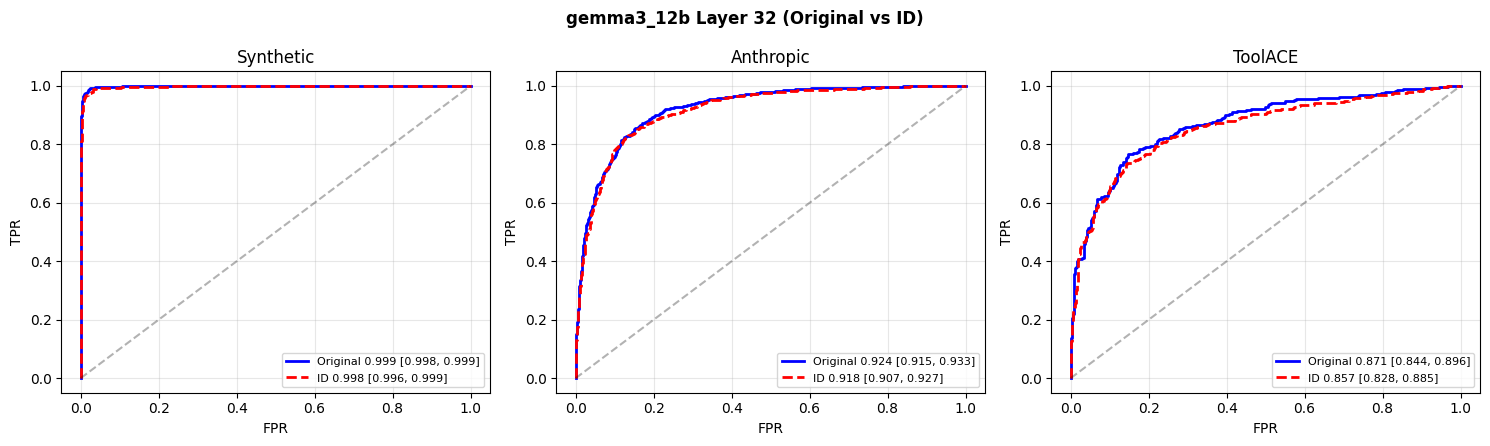

In [7]:
# Pick best layer (highest mean Original AUROC across seeds)
if len(LAYERS) == 1:
    plot_layer = LAYERS[0]
else:
    mean_aurocs = {}
    for l in LAYERS:
        aurocs_per_seed = []
        for s in range(N_SEEDS):
            en_mean = np.mean([all_results[l][s][ds]["auroc"] for ds in ["synthetic", "anthropic", "toolace"]])
            aurocs_per_seed.append(en_mean)
        mean_aurocs[l] = np.mean(aurocs_per_seed)
    plot_layer = max(mean_aurocs, key=mean_aurocs.get)
    print(f"Best Original mean AUROC: layer {plot_layer} ({mean_aurocs[plot_layer]:.4f})")

# Use canonical probe (seed 0) for ROC curves
probe_plot = LinearProbe.load(CACHE_DIR / f"{CACHE_PREFIX}_probe_layer{plot_layer}.pkl")

# Load activations from cache
X_test_plot      = get_activations_cached(model, tokenizer, test_data, plot_layer,
                       cache_name="test_synthetic", cache_dir=CACHE_DIR,
                       cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE)
X_anthropic_plot = get_activations_cached(model, tokenizer, anthropic_test, plot_layer,
                       cache_name="anthropic_test", cache_dir=CACHE_DIR,
                       cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE)
X_toolace_plot   = get_activations_cached(model, tokenizer, toolace_test, plot_layer,
                       cache_name="toolace_test", cache_dir=CACHE_DIR,
                       cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE)

n_cols = 3
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4.5))

plot_sets = [
    ("Synthetic", X_test_plot,      y_test),
    ("Anthropic", X_anthropic_plot, y_anthropic),
    ("ToolACE",   X_toolace_plot,   y_toolace),
]

for ax, (name, X_en, y_en) in zip(axes, plot_sets):
    probs_en = probe_plot.predict_proba(X_en)
    fpr_en, tpr_en, _ = roc_curve(y_en, probs_en)
    auroc_en, ci_lo, ci_hi = bootstrap_auroc_ci(y_en, probs_en, N_BOOTSTRAP, CI_LEVEL)
    ax.plot(fpr_en, tpr_en, "b-", lw=2, label=f"Original {auroc_en:.3f} [{ci_lo:.3f}, {ci_hi:.3f}]")

    if EVAL_INDONESIAN:
        id_cache_map = {"Synthetic": "id_test_synthetic", "Anthropic": "id_anthropic_test", "ToolACE": "id_toolace_test"}
        id_data_map  = {"Synthetic": id_test_data, "Anthropic": id_anthropic_test, "ToolACE": id_toolace_test}
        id_label_map = {"Synthetic": y_id_test, "Anthropic": y_id_anthropic, "ToolACE": y_id_toolace}
        X_id_plot = get_activations_cached(model, tokenizer, id_data_map[name], plot_layer,
                        cache_name=id_cache_map[name], cache_dir=CACHE_DIR,
                        cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE)
        probs_id = probe_plot.predict_proba(X_id_plot)
        fpr_id, tpr_id, _ = roc_curve(id_label_map[name], probs_id)
        auroc_id, ci_lo_id, ci_hi_id = bootstrap_auroc_ci(id_label_map[name], probs_id, N_BOOTSTRAP, CI_LEVEL)
        ax.plot(fpr_id, tpr_id, "r--", lw=2, label=f"ID {auroc_id:.3f} [{ci_lo_id:.3f}, {ci_hi_id:.3f}]")

    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(name)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)

title = f"{MODEL_SHORT} Layer {plot_layer}"
if EVAL_INDONESIAN:
    title += " (Original vs ID)"
fig.suptitle(title, fontweight="bold")
plt.tight_layout()

fig_path = FIG_DIR / f"roc_layer{plot_layer}.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## Part 5: Layer Sweep Plot

Saved: /lambda/nfs/default-filesystem/bluedot-project/experiments/cache/figures/gemma3_12b/layer_sweep.png


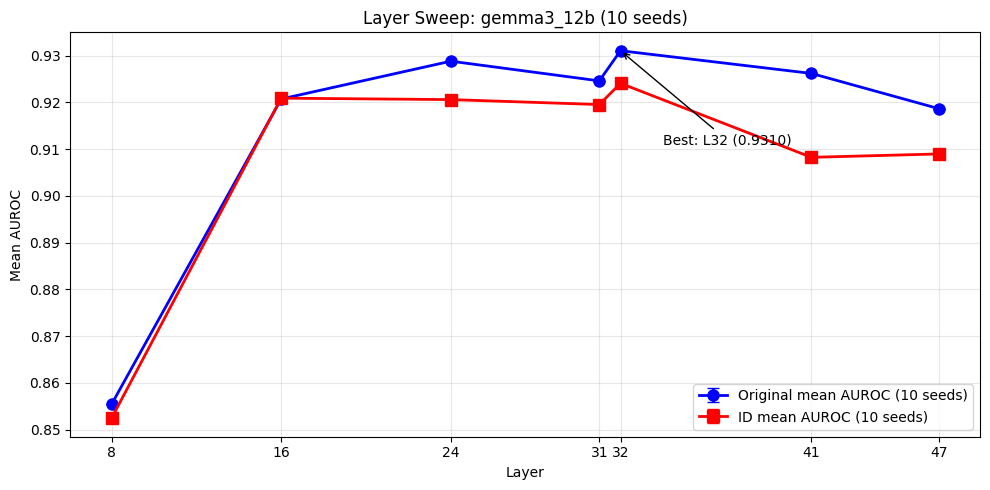

 Layer |       Orig synthetic |       Orig anthropic |         Orig toolace |         ID synthetic |         ID anthropic |           ID toolace
------------------------------------------------------------------------------------------------------------------------------------------------
     8 |   0.9941 +/- 0.0000 |   0.7872 +/- 0.0000 |   0.7850 +/- 0.0000 |   0.9898 +/- 0.0000 |   0.7836 +/- 0.0000 |   0.7838 +/- 0.0000
    16 |   0.9988 +/- 0.0000 |   0.9065 +/- 0.0000 |   0.8568 +/- 0.0000 |   0.9977 +/- 0.0000 |   0.8984 +/- 0.0000 |   0.8665 +/- 0.0000
    24 |   0.9990 +/- 0.0000 |   0.9342 +/- 0.0000 |   0.8531 +/- 0.0000 |   0.9982 +/- 0.0000 |   0.9246 +/- 0.0000 |   0.8389 +/- 0.0000
    31 |   0.9987 +/- 0.0000 |   0.9209 +/- 0.0000 |   0.8542 +/- 0.0000 |   0.9976 +/- 0.0000 |   0.9158 +/- 0.0000 |   0.8452 +/- 0.0000
    32 |   0.9987 +/- 0.0000 |   0.9238 +/- 0.0000 |   0.8706 +/- 0.0000 |   0.9975 +/- 0.0000 |   0.9176 +/- 0.0000 |   0.8571 +/- 0.0000
    41 |   0.99

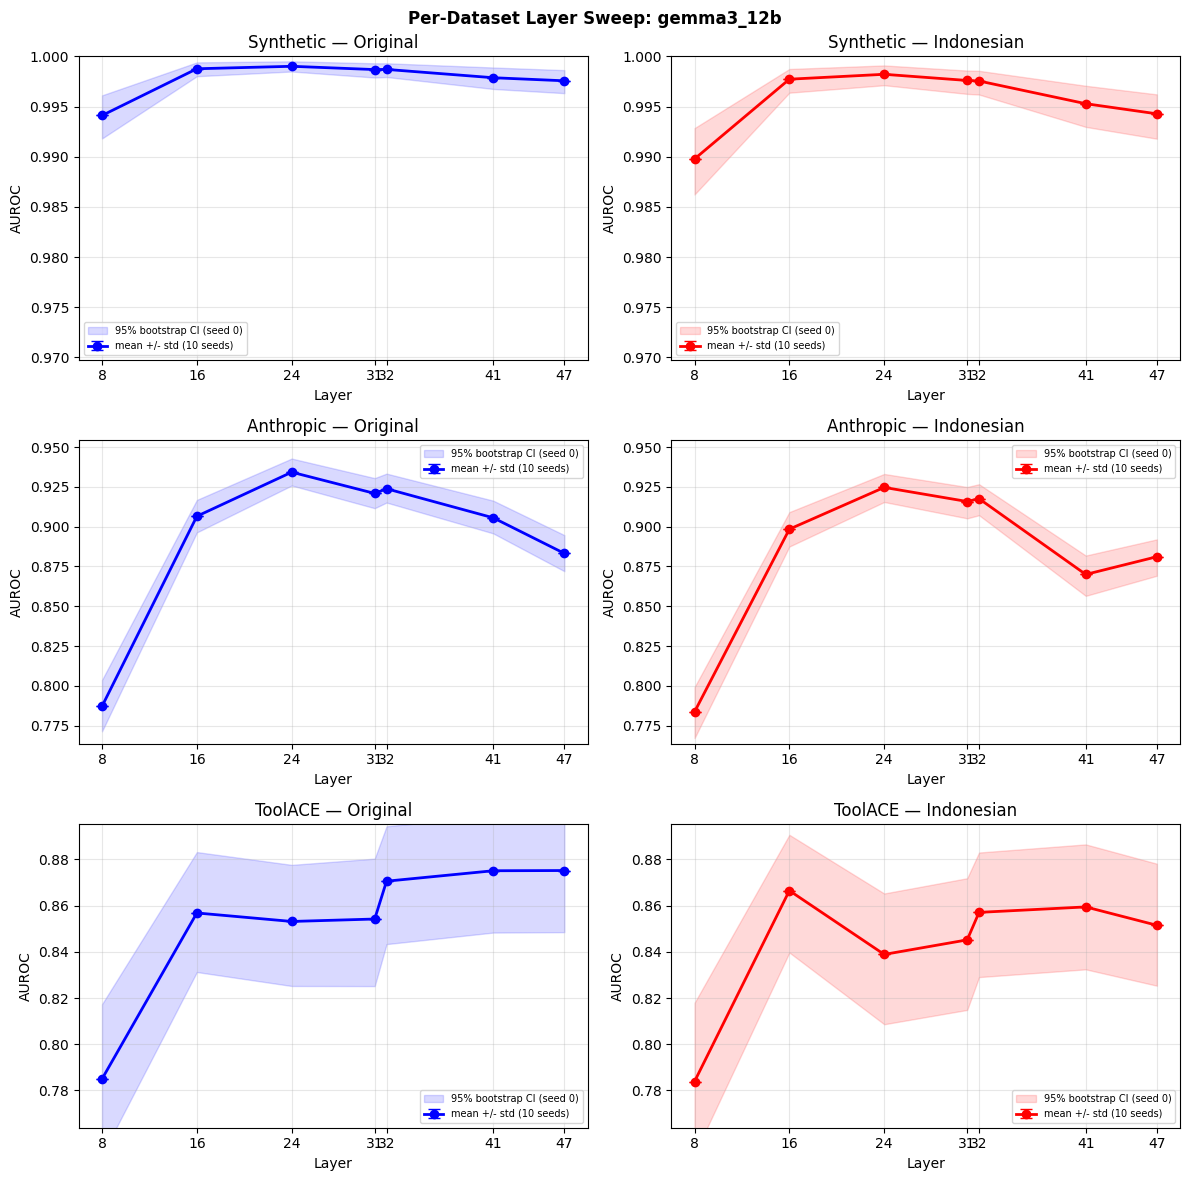

In [8]:
if len(LAYERS) > 1:
    layers = sorted(all_results.keys())

    # compute mean +/- std across seeds for Original and ID
    def auroc_stats(layer, ds_names):
        """Return (mean_across_seeds, std_across_seeds) of per-seed mean AUROC."""
        per_seed = []
        for s in range(N_SEEDS):
            mean_auroc = np.mean([all_results[layer][s][ds]["auroc"] for ds in ds_names])
            per_seed.append(mean_auroc)
        return np.mean(per_seed), np.std(per_seed)

    en_means = [auroc_stats(l, ["synthetic", "anthropic", "toolace"])[0] for l in layers]
    en_stds  = [auroc_stats(l, ["synthetic", "anthropic", "toolace"])[1] for l in layers]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.errorbar(layers, en_means, yerr=en_stds, fmt="b-o", lw=2, ms=8, capsize=4,
                label=f"Original mean AUROC ({N_SEEDS} seeds)")

    if EVAL_INDONESIAN:
        id_means = [auroc_stats(l, ["id_synthetic", "id_anthropic", "id_toolace"])[0] for l in layers]
        id_stds  = [auroc_stats(l, ["id_synthetic", "id_anthropic", "id_toolace"])[1] for l in layers]
        ax.errorbar(layers, id_means, yerr=id_stds, fmt="r-s", lw=2, ms=8, capsize=4,
                    label=f"ID mean AUROC ({N_SEEDS} seeds)")

    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean AUROC")
    ax.set_title(f"Layer Sweep: {MODEL_SHORT} ({N_SEEDS} seeds)")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xticks(layers)

    best_layer = layers[np.argmax(en_means)]
    best_val   = max(en_means)
    ax.annotate(f"Best: L{best_layer} ({best_val:.4f})",
                xy=(best_layer, best_val),
                xytext=(best_layer + 2, best_val - 0.02),
                arrowprops=dict(arrowstyle="->"), fontsize=10)

    plt.tight_layout()
    fig_path = FIG_DIR / "layer_sweep.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()

    # per-dataset breakdown table with mean +/- std
    all_ds = ["synthetic", "anthropic", "toolace"]
    if EVAL_INDONESIAN:
        all_ds += ["id_synthetic", "id_anthropic", "id_toolace"]

    header = f"{'Layer':>6}"
    for ds in all_ds:
        label = f"{'ID ' if ds.startswith('id_') else 'Orig '}{ds.replace('id_','')}"
        header += f" | {label:>20}"
    print(header)
    print("-" * len(header))
    for l in layers:
        row = f"{l:>6}"
        for ds in all_ds:
            aurocs = [all_results[l][s][ds]["auroc"] for s in range(N_SEEDS)]
            row += f" | {np.mean(aurocs):>8.4f} +/- {np.std(aurocs):.4f}"
        print(row)

    # --- Per-dataset layer sweep: one row per dataset, Original + ID side by side ---
    dataset_pairs = [
        ("Synthetic",  "synthetic",  "id_synthetic"),
        ("Anthropic",  "anthropic",  "id_anthropic"),
        ("ToolACE",    "toolace",    "id_toolace"),
    ]
    n_rows = len(dataset_pairs)
    n_cols = 2 if EVAL_INDONESIAN else 1

    fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows),
                               squeeze=False)

    for row_i, (ds_label, orig_ds, id_ds) in enumerate(dataset_pairs):
        # collect all AUROC values across both variants to set shared y-axis
        all_aurocs_row = []

        for col_i, (ds, variant_label, color) in enumerate([
            (orig_ds, "Original", "b"),
            (id_ds,   "Indonesian", "r"),
        ]):
            if col_i >= n_cols:
                break
            ax2 = axes2[row_i, col_i]

            means, stds, ci_lo_list, ci_hi_list = [], [], [], []
            for l in layers:
                aurocs = [all_results[l][s][ds]["auroc"] for s in range(N_SEEDS)]
                means.append(np.mean(aurocs))
                stds.append(np.std(aurocs))
                ci_lo_list.append(all_results[l][0][ds]["ci_lower"])
                ci_hi_list.append(all_results[l][0][ds]["ci_upper"])
                all_aurocs_row.extend(aurocs)

            ax2.errorbar(layers, means, yerr=stds, fmt=f"{color}-o", lw=2, ms=6, capsize=4,
                         label=f"mean +/- std ({N_SEEDS} seeds)")
            ax2.fill_between(layers, ci_lo_list, ci_hi_list, alpha=0.15, color=color,
                             label="95% bootstrap CI (seed 0)")
            ax2.set_title(f"{ds_label} — {variant_label}")
            ax2.set_xlabel("Layer")
            ax2.set_ylabel("AUROC")
            ax2.set_xticks(layers)
            ax2.legend(fontsize=7)
            ax2.grid(alpha=0.3)

        # shared y-axis limits within each row
        if all_aurocs_row:
            y_min = min(all_aurocs_row) - 0.02
            y_max = max(all_aurocs_row) + 0.02
            # clamp to [0, 1]
            y_min = max(0, y_min)
            y_max = min(1, y_max)
            for col_i in range(n_cols):
                axes2[row_i, col_i].set_ylim(y_min, y_max)

    fig2.suptitle(f"Per-Dataset Layer Sweep: {MODEL_SHORT}", fontweight="bold")
    plt.tight_layout()
    fig_path2 = FIG_DIR / "layer_sweep_per_dataset.png"
    plt.savefig(fig_path2, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path2}")
    plt.show()

else:
    print("Single layer evaluated -- no sweep plot needed.")

## Part 6: Error Analysis

In [9]:
# Error analysis using canonical probe (seed 0) at best layer
probe_err = LinearProbe.load(CACHE_DIR / f"{CACHE_PREFIX}_probe_layer{plot_layer}.pkl")

analyze_errors(probe_err, X_test_plot, test_data, "Original Synthetic")
analyze_errors(probe_err, X_anthropic_plot, anthropic_test, "Original Anthropic")
analyze_errors(probe_err, X_toolace_plot, toolace_test, "Original ToolACE")

if EVAL_INDONESIAN:
    X_id_test_plot = get_activations_cached(model, tokenizer, id_test_data, plot_layer,
                         cache_name="id_test_synthetic", cache_dir=CACHE_DIR,
                         cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE)
    analyze_errors(probe_err, X_id_test_plot, id_test_data, "ID Synthetic")


ERROR ANALYSIS: Original Synthetic
Total errors: 36 / 2000 (1.8%)
False positives: 10
False negatives: 26

--- FALSE POSITIVES (predicted high, actually low) ---

P=0.944 | ID: Z8Ob5Xb2
  Reflecting on the recent incident at our research facility, I am gripped by a persistent unease. I trusted the upgraded data integrity system implicitly, and now it's clear that reliance left us expos...

P=0.889 | ID: OAVPnS9W
  पहले से ज्ञात नियमों की अनदेखी के चलते इस अनियंत्रित संकट का दोष किस पर डालेगा यह फिल्म दल? 

P=0.848 | ID: UD5d1Ncd
  "Can we really ignore this? It's alarming! The speaker failed at a simple task; what about more complex commands?"

P=0.810 | ID: ah1fxAcV
  I'm anxious, watching the plumbers work. They assure us the bathrooms are safe, but my mind lingers on potential slip hazards. I plead for diligence because these spaces are crucial for our well-being...

P=0.722 | ID: IdpXvTfW
   I gaze at the touchscreen, biting my lip nervously, trying to predict Telos-C's potential.

## Part 7: Sense Checks

1. Training accuracy (overfitting check)
2. Random label baseline (should be ~0.5 AUROC)
3. Per-source-language breakdown of synthetic test set

In [10]:
probe_check = LinearProbe.load(CACHE_DIR / f"{CACHE_PREFIX}_probe_layer{plot_layer}.pkl")
X_train_check = get_activations_cached(model, tokenizer, train_data, plot_layer,
                    cache_name="train", cache_dir=CACHE_DIR,
                    cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE)

# 1. Training accuracy
train_metrics = evaluate_probe(probe_check, X_train_check, y_train, "Training Set (overfitting check)")

# 2. Random baseline
rng            = np.random.RandomState(MASTER_SEED)
y_shuffled     = rng.permutation(y_train)
random_probe   = LinearProbe(C=1e-3, random_state=SEEDS[0])
random_probe.fit(X_train_check, y_shuffled)
random_metrics = evaluate_probe(random_probe, X_test_plot, y_test, "Random Labels Baseline")

# 3. Per-source-language breakdown
raw_test  = load_jsonl(DATASET_PATHS["test"])
languages = [row.get("language", "English") for row in raw_test]

print("\n--- Per-Source-Language Breakdown ---")
for lang in sorted(set(languages)):
    mask    = np.array([l == lang for l in languages])
    n_total = mask.sum()
    if n_total < 10:
        continue
    X_lang = X_test_plot[mask]
    y_lang = y_test[mask]
    probs  = probe_check.predict_proba(X_lang)
    auroc, ci_lo, ci_hi = bootstrap_auroc_ci(y_lang, probs, N_BOOTSTRAP, CI_LEVEL)
    n_high = int(y_lang.sum())
    print(f"  {lang:12s}: AUROC={auroc:.4f} [{ci_lo:.4f}, {ci_hi:.4f}]  ({n_total} examples, {n_high} high)")

Loading from cache: v2b_gemma3_12b_train_layer32.npy

Training Set (overfitting check):
  AUROC:      0.9998
  Accuracy:   0.9944
  TPR@1%FPR:  0.9970
  TPR@5%FPR:  0.9995

Random Labels Baseline:
  AUROC:      0.4613
  Accuracy:   0.4795
  TPR@1%FPR:  0.0030
  TPR@5%FPR:  0.0270

--- Per-Source-Language Breakdown ---
  English     : AUROC=0.9981 [0.9968, 0.9991]  (1172 examples, 595 high)
  French      : AUROC=0.9998 [0.9992, 1.0000]  (275 examples, 134 high)
  German      : AUROC=1.0000 [1.0000, 1.0000]  (289 examples, 142 high)
  Hindi       : AUROC=0.9990 [0.9968, 1.0000]  (264 examples, 129 high)


## Part 8: Save Artifacts

In [11]:
# Build results dict — serialize all_results with seed structure
serializable_results = {}
for layer in LAYERS:
    layer_dict = {}
    for seed_idx in range(N_SEEDS):
        seed_dict = {}
        for ds_name, metrics in all_results[layer][seed_idx].items():
            seed_dict[ds_name] = {k: float(v) for k, v in metrics.items()}
        layer_dict[str(seed_idx)] = seed_dict
    serializable_results[str(layer)] = layer_dict

# Aggregate stats for quick reference
aggregate = {}
for layer in LAYERS:
    layer_agg = {}
    all_ds = list(all_results[layer][0].keys())
    for ds in all_ds:
        aurocs = [all_results[layer][s][ds]["auroc"] for s in range(N_SEEDS)]
        layer_agg[ds] = {
            "auroc_mean":     float(np.mean(aurocs)),
            "auroc_std":      float(np.std(aurocs)),
            "auroc_seeds":    [float(a) for a in aurocs],
            "bootstrap_ci95": [
                float(all_results[layer][0][ds]["ci_lower"]),
                float(all_results[layer][0][ds]["ci_upper"]),
            ],
        }
    aggregate[str(layer)] = layer_agg

artifacts = {
    "version":         "v2b",
    "model_name":      MODEL_NAME,
    "model_short":     MODEL_SHORT,
    "layers":          LAYERS,
    "eval_indonesian": EVAL_INDONESIAN,
    "master_seed":     MASTER_SEED,
    "n_seeds":         N_SEEDS,
    "seeds":           SEEDS,
    "n_bootstrap":     N_BOOTSTRAP,
    "ci_level":        CI_LEVEL,
    "aggregate":       aggregate,
    "per_seed":        serializable_results,
    "data_sizes": {
        "en_train":     len(train_data),
        "en_test":      len(test_data),
        "en_anthropic": len(anthropic_test),
        "en_toolace":   len(toolace_test),
    },
}
if EVAL_INDONESIAN:
    artifacts["data_sizes"].update({
        "id_test":      len(id_test_data),
        "id_anthropic": len(id_anthropic_test),
        "id_toolace":   len(id_toolace_test),
    })

results_path = CACHE_DIR / f"{CACHE_PREFIX}_results.json"
with open(results_path, "w") as f:
    json.dump(artifacts, f, indent=2)
print(f"Results saved to {results_path.name}")
print(f"Figures saved to {FIG_DIR}/")

list_cache(CACHE_DIR, prefix=CACHE_PREFIX)
download_from_colab(CACHE_DIR, results_path.name, CACHE_PREFIX)

Results saved to v2b_gemma3_12b_results.json
Figures saved to /lambda/nfs/default-filesystem/bluedot-project/experiments/cache/figures/gemma3_12b/

Cache directory: /lambda/nfs/default-filesystem/bluedot-project/experiments/cache
--------------------------------------------------
  v2b_gemma3_12b_anthropic_test_layer16.npy        43.71 MB
  v2b_gemma3_12b_anthropic_test_layer24.npy        43.71 MB
  v2b_gemma3_12b_anthropic_test_layer31.npy        43.71 MB
  v2b_gemma3_12b_anthropic_test_layer32.npy        43.71 MB
  v2b_gemma3_12b_anthropic_test_layer41.npy        43.71 MB
  v2b_gemma3_12b_anthropic_test_layer47.npy        43.71 MB
  v2b_gemma3_12b_anthropic_test_layer8.npy         43.71 MB
  v2b_gemma3_12b_id_anthropic_test_layer16.npy     43.34 MB
  v2b_gemma3_12b_id_anthropic_test_layer24.npy     43.34 MB
  v2b_gemma3_12b_id_anthropic_test_layer31.npy     43.34 MB
  v2b_gemma3_12b_id_anthropic_test_layer32.npy     43.34 MB
  v2b_gemma3_12b_id_anthropic_test_layer41.npy     43.34 MB